In [1]:
# Cell 1
%matplotlib inline
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

warnings.filterwarnings('ignore', message='.*SQLAlchemy.*', category=UserWarning)

sys.path.insert(0, '../../../..')
import scripts.shared.db_utils as _dbu

ROOT = Path(_dbu.__file__).parent.parent.parent
OUT  = ROOT / 'output' / 'edop' / 'demo'
OUT.mkdir(parents=True, exist_ok=True)

conn = _dbu.db_connect()
print(f'Connected. Output -> {OUT}')

Connected. Output -> /Users/karlg/Documents/repos/_edops/output/edop/demo


## Step 1 — Characterise the space

In [2]:
# Cell 2 — column inventory + NoData audit
# Confirm which candidate columns exist in basin06.
# For each present column: count -9999 sentinel and NULL; compute vmin/vmax.
# Temperature cols (tmp_dc_*) stored x10 in DB — display values divided by 10.

NODATA    = -9999
TEMP_COLS = {'tmp_dc_syr', 'tmp_dc_smx', 'tmp_dc_smn', 'tmp_dc_uyr'}

# (band, label, modern_only, log_transform)
CANDIDATE_COLS = {
    'ele_mt_sav': ('A', 'Elevation mean',       False, False),
    'ele_mt_smx': ('A', 'Elevation max',        False, False),
    'ele_mt_smn': ('A', 'Elevation min',        False, False),
    'slp_dg_sav': ('A', 'Slope',                False, False),
    'sgr_dk_sav': ('A', 'Stream gradient',      False, True),
    'kar_pc_sse': ('A', 'Karst',                False, False),
    'dis_m3_pyr': ('B', 'Discharge annual',     False, True),
    'dis_m3_pmx': ('B', 'Discharge max',        False, True),
    'dis_m3_pmn': ('B', 'Discharge min',        False, True),
    'run_mm_syr': ('B', 'Runoff annual',        False, False),
    'gwt_cm_sav': ('B', 'Groundwater depth',    False, False),
    'wet_pc_sg1': ('B', 'Wetland grp1',         False, False),
    'wet_pc_sg2': ('B', 'Wetland grp2',         False, False),
    'ria_ha_ssu': ('B', 'River area',           False, True),
    'cly_pc_sav': ('B', 'Clay',                 False, False),
    'slt_pc_sav': ('B', 'Silt',                 False, False),
    'snd_pc_sav': ('B', 'Sand (compositional)', False, False),
    'ari_ix_sav': ('C', 'Aridity index',        False, True),
    'pre_mm_syr': ('C', 'Precip annual',        False, False),
    'tmp_dc_syr': ('C', 'Temp annual (x10)',    False, False),
    'tmp_dc_smx': ('C', 'Temp max (x10)',       False, False),
    'tmp_dc_smn': ('C', 'Temp min (x10)',       False, False),
    'prm_pc_sse': ('C', 'Permafrost',           False, False),
    'snw_pc_syr': ('C', 'Snow cover annual',    False, False),
    'crp_pc_sse': ('D', 'Cropland (modern)',    True,  False),
    'pst_pc_sse': ('D', 'Pasture (modern)',     True,  False),
    'hft_ix_s09': ('D', 'Human footprint',      True,  False),
    'dist_sink':  ('E', 'Dist to outlet',       False, False),
    'ari_ix_uav': ('u', 'Aridity upstream',     False, True),
    'pre_mm_uyr': ('u', 'Precip upstream',      False, False),
    'tmp_dc_uyr': ('u', 'Temp upstream (x10)',  False, False),
}

existing = pd.read_sql("""
    SELECT column_name FROM information_schema.columns
    WHERE table_schema = 'public' AND table_name = 'basin06'
    ORDER BY ordinal_position
""", conn)['column_name'].tolist()

present = [c for c in CANDIDATE_COLS if c in existing]
absent  = [c for c in CANDIDATE_COLS if c not in existing]
print(f'Present: {len(present)}  Absent: {absent}')

rows = []
for col in present:
    band, label, modern, log_t = CANDIDATE_COLS[col]
    df = pd.read_sql(f"""
        SELECT COUNT(*)                                          AS n,
               COUNT(CASE WHEN {col} = {NODATA} THEN 1 END)    AS n_nd,
               COUNT(CASE WHEN {col} IS NULL     THEN 1 END)   AS n_null,
               MIN(CASE WHEN {col} != {NODATA}   THEN {col} END) AS vmin,
               MAX(CASE WHEN {col} != {NODATA}   THEN {col} END) AS vmax
        FROM public.basin06
    """, conn)
    r     = df.iloc[0]
    scale = 10 if col in TEMP_COLS else 1
    bad   = int(r.n_nd) + int(r.n_null)
    rows.append({
        'band': band, 'col': col, 'label': label,
        'n': int(r.n), 'n_bad': bad,
        'pct_bad': round(100 * bad / int(r.n), 1),
        'vmin': round(float(r.vmin) / scale, 2) if r.vmin is not None else None,
        'vmax': round(float(r.vmax) / scale, 2) if r.vmax is not None else None,
        'modern': modern, 'log': log_t,
    })

audit = pd.DataFrame(rows)
print(audit[['band','col','label','n_bad','pct_bad','vmin','vmax','modern']].to_string(index=False))

band        col                label  n_bad  pct_bad   vmin      vmax  modern
   A ele_mt_sav       Elevation mean      0      0.0  -30.0   5556.00   False
   A ele_mt_smx        Elevation max      0      0.0  -30.0   8654.00   False
   A ele_mt_smn        Elevation min      0      0.0 -598.0   5186.00   False
   A slp_dg_sav                Slope    302      1.8    0.0    306.00   False
   A sgr_dk_sav      Stream gradient    412      2.5    0.0   1969.00   False
   A kar_pc_sse                Karst      0      0.0    0.0    100.00   False
   B dis_m3_pyr     Discharge annual      0      0.0    0.0 205605.02   False
   B dis_m3_pmx        Discharge max      0      0.0    0.0 290310.47   False
   B dis_m3_pmn        Discharge min      0      0.0    0.0 125376.69   False
   B run_mm_syr        Runoff annual      0      0.0    0.0   5696.00   False
   B gwt_cm_sav    Groundwater depth      0      0.0    0.0   1787.00   False
   B wet_pc_sg1         Wetland grp1      0      0.0    0.0    1

In [3]:
# Cell 3 — load basin06; mask NoData; scale temperatures
# Columns with pct_bad > 20 excluded from analysis matrix.
# -9999 -> NaN; temperature cols / 10.

good_cols = audit[audit['pct_bad'] <= 20]['col'].tolist()
bad_cols  = audit[audit['pct_bad'] >  20]['col'].tolist()
print(f'Good cols ({len(good_cols)}): {good_cols}')
print(f'Excluded  ({len(bad_cols)}):  {bad_cols}')

sql_cols = ', '.join(['hybas_id'] + good_cols)
raw = pd.read_sql(f'SELECT {sql_cols} FROM public.basin06', conn)

for c in TEMP_COLS:
    if c in raw.columns:
        raw[c] = raw[c] / 10.0

for c in good_cols:
    raw[c] = raw[c].replace(NODATA, np.nan)

print(f'\nLoaded {len(raw):,} basins x {len(good_cols)} columns')
print('Remaining NaN counts:')
print(raw[good_cols].isna().sum().sort_values(ascending=False).head(8))


Loaded 16,397 basins x 31 columns
Remaining NaN counts:
slt_pc_sav    757
cly_pc_sav    757
snd_pc_sav    757
sgr_dk_sav    412
slp_dg_sav    302
snw_pc_syr      5
ari_ix_uav      0
dist_sink       0
dtype: int64


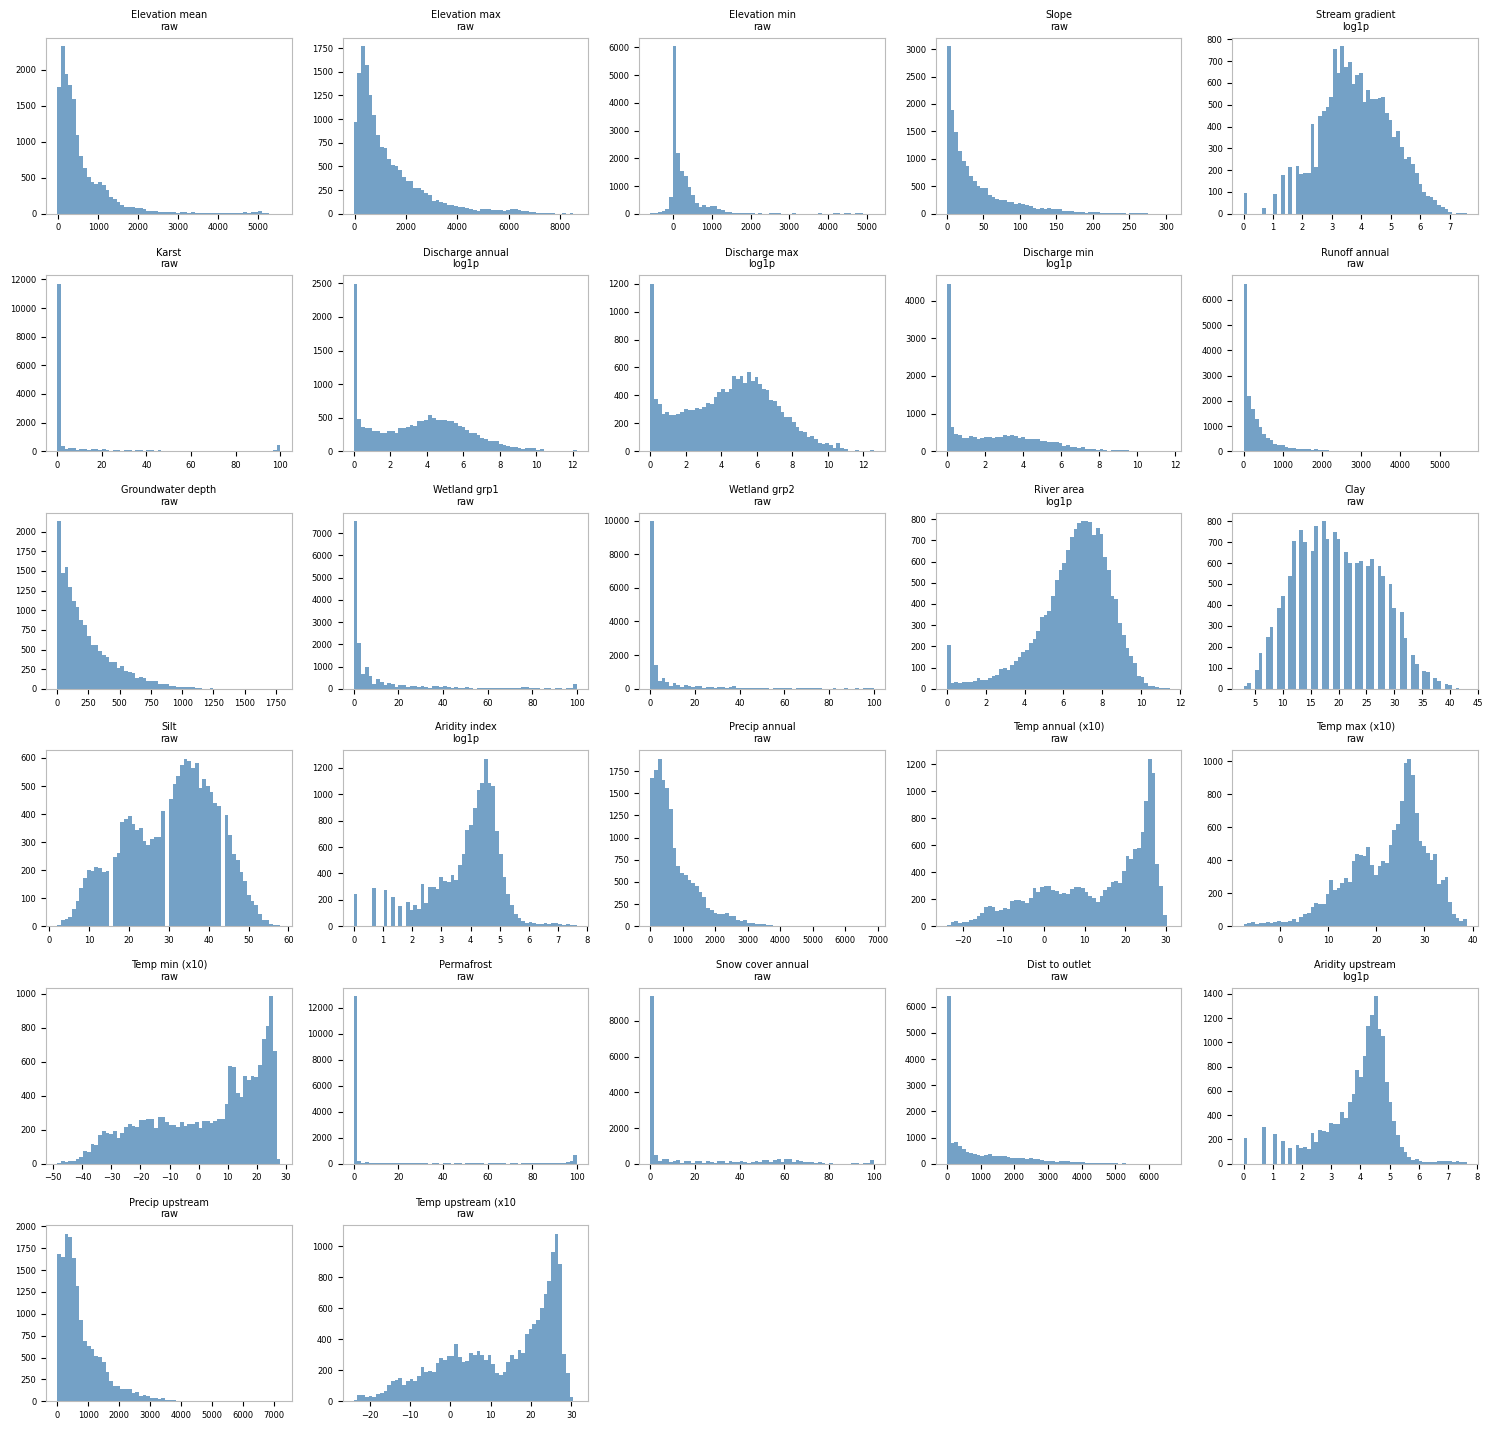

In [4]:
# Cell 4 — log transforms + marginal distributions
# Build tf: log1p applied to high-skew columns (catalog-confirmed).
# Sand excluded globally (compositional with clay+silt).
# Modern-only Band D kept in tf for correlation audit; excluded from comparison vector later.

from IPython.display import Image as IPImage

LOG_COLS = {'dis_m3_pyr', 'dis_m3_pmx', 'dis_m3_pmn', 'ria_ha_ssu',
            'ari_ix_sav', 'ari_ix_uav', 'sgr_dk_sav'}

ANALYSIS_COLS = [c for c in good_cols if c != 'snd_pc_sav']

tf = raw[ANALYSIS_COLS].copy()
for c in LOG_COLS:
    if c in tf.columns:
        tf[c] = np.log1p(tf[c].clip(lower=0))

# Skewness on raw values for documentation
skews = {c: float(raw[c].dropna().skew()) for c in ANALYSIS_COLS if c in raw.columns}
print('Skewness (raw, top 12 by |skew|):')
for c, sk in sorted(skews.items(), key=lambda x: abs(x[1]), reverse=True)[:12]:
    flag = '<- log applied' if c in LOG_COLS else ''
    print(f'  {c:<20} {sk:+6.2f}  {flag}')

# Distribution grid (non-modern-only)
plot_cols = [c for c in ANALYSIS_COLS if not CANDIDATE_COLS.get(c, ('','',True,''))[2]]
ncols_g   = 5
nrows_g   = (len(plot_cols) + ncols_g - 1) // ncols_g
fig, axes = plt.subplots(nrows_g, ncols_g, figsize=(15, 2.4 * nrows_g))
axes_f    = axes.flatten()

for i, col in enumerate(plot_cols):
    ax  = axes_f[i]
    v   = tf[col].dropna()
    ax.hist(v, bins=60, color='steelblue', alpha=0.75, edgecolor='none')
    lbl = CANDIDATE_COLS[col][1][:18]
    ax.set_title(f'{lbl}\n{"log1p" if col in LOG_COLS else "raw"}', fontsize=7, color='black')
    ax.tick_params(labelsize=6, colors='black')
    ax.set_facecolor('white')
    for sp in ax.spines.values(): sp.set_edgecolor('#bbbbbb')

for j in range(i + 1, len(axes_f)):
    axes_f[j].set_visible(False)

fig.patch.set_facecolor('white')
fig.tight_layout()
out_p = OUT / 'wo4c_marginal_distributions.png'
fig.savefig(out_p, facecolor='white', dpi=100, bbox_inches='tight')
plt.close(fig)
display(IPImage(str(out_p)))

In [5]:
# Cell 5 — correlation matrix
# Exclude modern-only Band D. Pearson on pairwise-complete (min_periods=500).

CORR_COLS = [c for c in ANALYSIS_COLS
             if not CANDIDATE_COLS.get(c, ('','',True,''))[2]]

corr = tf[CORR_COLS].corr(method='pearson', min_periods=500)

fig, ax = plt.subplots(figsize=(13, 11))
im  = ax.imshow(corr.values, vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
lbls = [CANDIDATE_COLS[c][1][:16] if c in CANDIDATE_COLS else c for c in corr.columns]
ax.set_xticks(range(len(lbls))); ax.set_xticklabels(lbls, rotation=45, ha='right', fontsize=7, color='black')
ax.set_yticks(range(len(lbls))); ax.set_yticklabels(lbls, fontsize=7, color='black')
plt.colorbar(im, ax=ax, shrink=0.7)
ax.set_title('Pearson correlation — basin06 L06 (log-transformed; modern-only excluded)', color='black')
fig.patch.set_facecolor('white'); ax.set_facecolor('white')
fig.tight_layout()
out_p = OUT / 'wo4c_correlation_matrix.png'
fig.savefig(out_p, facecolor='white', dpi=120, bbox_inches='tight')
plt.close(fig)
display(IPImage(str(out_p)))

print('High-correlation pairs (|r| >= 0.85, excl. self):')
for c1 in corr.columns:
    for c2 in corr.columns:
        if c1 < c2 and abs(corr.loc[c1, c2]) >= 0.85:
            print(f'  {c1:<20} <-> {c2:<20}  r={corr.loc[c1, c2]:+.3f}')

corr.to_csv(OUT / 'wo4c_correlation_matrix.tsv', sep='\t')
print('\nSaved wo4c_correlation_matrix.tsv')

High-correlation pairs (|r| >= 0.85, excl. self):
  dis_m3_pmx           <-> dis_m3_pyr            r=+0.972
  dis_m3_pmn           <-> dis_m3_pyr            r=+0.943
  dis_m3_pmn           <-> dis_m3_pmx            r=+0.878
  wet_pc_sg1           <-> wet_pc_sg2            r=+0.881
  ari_ix_sav           <-> ari_ix_uav            r=+0.975
  pre_mm_syr           <-> pre_mm_uyr            r=+0.973
  tmp_dc_syr           <-> tmp_dc_uyr            r=+0.990
  tmp_dc_smx           <-> tmp_dc_syr            r=+0.903
  tmp_dc_smx           <-> tmp_dc_uyr            r=+0.886
  tmp_dc_smn           <-> tmp_dc_syr            r=+0.976
  tmp_dc_smn           <-> tmp_dc_uyr            r=+0.971
  snw_pc_syr           <-> tmp_dc_syr            r=-0.895
  snw_pc_syr           <-> tmp_dc_smn            r=-0.852
  snw_pc_syr           <-> tmp_dc_uyr            r=-0.881

Saved wo4c_correlation_matrix.tsv


In [6]:
# Cell 6 — PCA: dimensionality + Sigma conditioning
# kappa = sigma_max / sigma_min. kappa > 1000 -> Mahalanobis unreliable over full set.

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pca_df = tf[CORR_COLS].dropna()
print(f'PCA input: {len(pca_df):,} basins x {len(CORR_COLS)} features  (dropped {len(tf)-len(pca_df):,} NaN rows)')

sc_pca  = StandardScaler()
X_pca   = sc_pca.fit_transform(pca_df)
Sigma   = np.cov(X_pca.T)
eigvals = np.linalg.eigvalsh(Sigma)
kappa   = float(eigvals.max() / max(eigvals[eigvals > 0].min(), 1e-12))
print(f'\nSigma condition number kappa: {kappa:.1f}')
verdict = ('SINGULAR  -- Mahalanobis unreliable over full set' if kappa > 1000 else
           'MODERATE  -- some near-collinear dims; test on selected subset' if kappa > 100 else
           'WELL-CONDITIONED -- Mahalanobis stable')
print(f'  -> {verdict}')

pca    = PCA()
pca.fit(X_pca)
cumvar = np.cumsum(pca.explained_variance_ratio_) * 100

print('\nCumulative variance explained:')
for n in [1, 2, 3, 4, 5, 6, 8, 10, 12]:
    if n <= len(cumvar):
        print(f'  PC1-{n:2d}: {cumvar[n-1]:.1f}%')
n_90 = int(np.searchsorted(cumvar, 90)) + 1
n_95 = int(np.searchsorted(cumvar, 95)) + 1
print(f'\nComponents for 90%: {n_90}   for 95%: {n_95}   (of {len(CORR_COLS)} total)')

n_pcs   = min(6, len(CORR_COLS))
load_df = pd.DataFrame(
    pca.components_[:n_pcs, :].T,
    index=[CANDIDATE_COLS.get(c, ('','c','',''))[1][:18] for c in CORR_COLS],
    columns=[f'PC{i+1}' for i in range(n_pcs)]
)
print('\nTop 4 loadings per PC:')
for pc in load_df.columns:
    top   = load_df[pc].abs().sort_values(ascending=False).head(4)
    items = '   '.join(f'{n}: {load_df.loc[n, pc]:+.2f}' for n in top.index)
    print(f'  {pc}: {items}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(cumvar)+1), cumvar, marker='o', markersize=3, color='steelblue')
ax.axhline(90, color='firebrick',  ls='--', lw=1, label='90%')
ax.axhline(95, color='darkorange', ls='--', lw=1, label='95%')
ax.set_xlabel('Components', color='black')
ax.set_ylabel('Cumulative variance (%)', color='black')
ax.set_title('PCA scree -- basin06 L06 (z-scored)', color='black')
ax.legend(facecolor='white', edgecolor='gray', labelcolor='black')
ax.tick_params(colors='black')
fig.patch.set_facecolor('white'); ax.set_facecolor('white')
for sp in ax.spines.values(): sp.set_edgecolor('#aaaaaa')
fig.tight_layout()
out_p = OUT / 'wo4c_pca_scree.png'
fig.savefig(out_p, facecolor='white', dpi=120, bbox_inches='tight')
plt.close(fig)
display(IPImage(str(out_p)))
print(f'kappa={kappa:.1f}  n_90={n_90}  n_95={n_95}'); print(load_df.round(2))

kappa=6091.8  n_90=9  n_95=12
                     PC1   PC2   PC3   PC4   PC5   PC6
Elevation mean     -0.10 -0.12  0.36  0.22  0.28  0.15
Elevation max      -0.10 -0.06  0.41  0.09  0.17 -0.06
Elevation min      -0.06 -0.14  0.24  0.27  0.35  0.34
Slope              -0.15  0.05  0.37 -0.11 -0.00 -0.23
Stream gradient    -0.15  0.02  0.39 -0.15 -0.06 -0.20
Karst              -0.05 -0.03  0.04  0.00  0.03 -0.18
Discharge annual   -0.03  0.32  0.02  0.37 -0.13 -0.13
Discharge max      -0.03  0.30  0.02  0.39 -0.18 -0.13
Discharge min      -0.01  0.32 -0.02  0.33 -0.07 -0.14
Runoff annual       0.05  0.29  0.14 -0.31  0.11 -0.03
Groundwater depth   0.01 -0.15  0.34 -0.02 -0.07 -0.39
Wetland grp1       -0.01  0.12 -0.24  0.11  0.54 -0.28
Wetland grp2        0.01  0.10 -0.21  0.07  0.56 -0.31
River area         -0.05  0.27  0.10  0.17 -0.19 -0.11
Clay                0.27  0.10  0.12  0.02  0.01  0.07
Silt               -0.25  0.05 -0.05 -0.04 -0.09 -0.16
Aridity index      -0.11  0.34  0.0

## Step 2 — Variable selection per band

Revise `SELECTED` below based on Cell 5 correlation findings.
- Non-redundant: no selected pair with |r| > 0.80.
- Pre-1500 historically valid: exclude Band D (modern-only).
- Sand excluded globally (compositional with clay+silt).
- Catalog co-variation exclusions: discharge max/min co-vary with annual; temp_min co-varies with annual.

In [7]:
# Cell 7 — variable selection per band
# Decisions locked from Cell 2 (pct_bad audit), Cell 5 (correlation), Cell 7 redundancy check.

SELECTED = {
    'A_terrain': [
        'ele_mt_sav',   # elevation mean -- PC3 (terrain energy); continental-gradient
        'slp_dg_sav',   # slope -- PC3; primary terrain surface measure
        'kar_pc_sse',   # karst -- geological memory; local-anomaly; slow-change
        # sgr_dk_sav: r=+0.807 with slp_dg_sav -- excluded; slope is the more fundamental measure
    ],
    'B_hydrology': [
        'dis_m3_pyr',   # discharge annual (log) -- PC2+PC4; network integrator
        'gwt_cm_sav',   # groundwater depth -- slow variable; soil-water accessibility
        'wet_pc_sg1',   # wetland extent -- PC5; local-anomaly; floodplain
        'cly_pc_sav',   # clay -- water retention; substrate character
        'slt_pc_sav',   # silt -- distinct particle-size class from clay
        # run_mm_syr: r=+0.838 with pre_mm_syr -- excluded; net-of-evaporation signal
        #   already covered by ari_ix_sav (P/PET) + dis_m3_pyr (catchment-integrated runoff)
        # dis_m3_pmx r=+0.972, dis_m3_pmn r=+0.943 with dis_m3_pyr (Cell 5) -- excluded
        # wet_pc_sg2 r=+0.881 with wet_pc_sg1 (Cell 5) -- excluded
        # snd_pc_sav: compositional with clay+silt -- excluded globally
    ],
    'C_climate': [
        'ari_ix_sav',   # aridity index (log) -- PC2; moisture balance integrator (P/PET)
        'pre_mm_syr',   # precip annual -- PC2; direct water input
        'tmp_dc_syr',   # temperature annual -- PC1 dominant; thermal regime
        'prm_pc_sse',   # permafrost -- PC1; integrative cold signal; slow-change
        # tmp_dc_smx r=+0.903 with tmp_dc_syr (Cell 5) -- excluded
        # tmp_dc_smn r=+0.976 with tmp_dc_syr (Cell 5) -- excluded
        # snw_pc_syr r=-0.895 with tmp_dc_syr (Cell 5) -- excluded; PC1 thermal captures cold signal
    ],
    'E_coastality': [
        'dist_sink',    # dist to outlet -- PC4 (provenance axis); interior/network-position signal
    ],
}

# Upstream values: used in combined framing (Test 3); kept separate from SELECTED bands.
# Global r with local equivalents: ari 0.975, pre 0.973, tmp 0.990 (Cell 5).
# Adds near-zero independent information for ordinary basins; matters only where PC4 fires.
UPSTREAM = [
    'ari_ix_uav',   # aridity upstream (log) -- allochthonous moisture signal
    'pre_mm_uyr',   # precip upstream -- absolute upstream moisture
]

ALL_LOCAL      = [c for band in SELECTED.values() for c in band]
avail_local    = [c for c in ALL_LOCAL if c in tf.columns]
avail_upstream = [c for c in UPSTREAM  if c in tf.columns]
avail_combined = avail_local + avail_upstream

print('Selected local variables:')
for band, cols in SELECTED.items():
    avail   = [c for c in cols if c in tf.columns]
    missing = [c for c in cols if c not in tf.columns]
    print(f'  {band}: {avail}' + (f'  [absent: {missing}]' if missing else ''))
print(f'\nUpstream (s/u framing): {avail_upstream}')
print(f'\nTotal: local={len(avail_local)}  upstream={len(avail_upstream)}  combined={len(avail_combined)}')

# Redundancy check on selected local vars
sub_idx  = [c for c in avail_local if c in corr.index]
sub_corr = corr.loc[sub_idx, sub_idx]
print('\nHigh-r pairs within SELECTED (|r| >= 0.80) -- should be empty:')
found = False
for c1 in sub_corr.columns:
    for c2 in sub_corr.columns:
        if c1 < c2 and abs(sub_corr.loc[c1, c2]) >= 0.80:
            print(f'  {c1:<20} <-> {c2:<20}  r={sub_corr.loc[c1, c2]:+.3f}  <- REVISE')
            found = True
if not found:
    print('  None -- selection is non-redundant.')

Selected local variables:
  A_terrain: ['ele_mt_sav', 'slp_dg_sav', 'kar_pc_sse']
  B_hydrology: ['dis_m3_pyr', 'gwt_cm_sav', 'wet_pc_sg1', 'cly_pc_sav', 'slt_pc_sav']
  C_climate: ['ari_ix_sav', 'pre_mm_syr', 'tmp_dc_syr', 'prm_pc_sse']
  E_coastality: ['dist_sink']

Upstream (s/u framing): ['ari_ix_uav', 'pre_mm_uyr']

Total: local=13  upstream=2  combined=15

High-r pairs within SELECTED (|r| >= 0.80) -- should be empty:
  None -- selection is non-redundant.


## Step 3 — Feature matrices + distance function

In [8]:
# Cell 8 — feature matrices
# tf is already log-transformed (Cell 4). Filter to selected columns, z-score.
# X_local: local-only. X_combined: local + upstream.
# Rows with any NaN dropped; hybas_id arrays stay row-aligned with matrix.

from sklearn.preprocessing import StandardScaler

def build_matrix(df, hybas_series, cols):
    sub  = df[cols].copy()
    mask = sub.notna().all(axis=1)
    sc   = StandardScaler()
    X    = sc.fit_transform(sub[mask])
    hids = hybas_series[mask.values].values
    return X, sc, hids

X_local,    sc_local,    hids_local    = build_matrix(tf, raw['hybas_id'], avail_local)
X_combined, sc_combined, hids_combined = build_matrix(tf, raw['hybas_id'], avail_combined)

print(f'X_local:    {X_local.shape}   ({len(hids_local):,} basins x {len(avail_local)} features)')
print(f'X_combined: {X_combined.shape}   ({len(hids_combined):,} basins x {len(avail_combined)} features)')
print(f'NaN dropped -- local: {len(tf)-len(hids_local):,}   combined: {len(tf)-len(hids_combined):,}')

X_local:    (15500, 13)   (15,500 basins x 13 features)
X_combined: (15500, 15)   (15,500 basins x 15 features)
NaN dropped -- local: 897   combined: 897


In [9]:
# Cell 9 — distance utilities + sanity check
# find_basin: PostGIS ST_Contains lookup.
# query_analogues: extracts query row from tf (already log-transformed),
#   z-scores via scaler, computes L2 distance to all basins in X.
#   Returns top_n nearest with per-band sub-distances.

def find_basin(lat, lon, conn, level=6):
    df = pd.read_sql(
        f"SELECT hybas_id FROM public.basin0{level} "
        f"WHERE ST_Contains(geom, ST_SetSRID(ST_MakePoint({lon}, {lat}), 4326)) LIMIT 1",
        conn)
    return int(df.iloc[0]['hybas_id']) if len(df) else None

def query_analogues(lat, lon, conn, X, sc, hids, col_list, top_n=20, label=''):
    q_id  = find_basin(lat, lon, conn)
    if q_id is None:
        print(f'{label}: no basin at ({lat}, {lon})')
        return None
    tf_row = tf[raw['hybas_id'] == q_id][col_list]
    if tf_row.empty or tf_row.iloc[0].isna().any():
        print(f'{label}: hybas_id {q_id} has NaN in feature columns')
        return None
    q_vec = sc.transform(tf_row.values)[0]
    diffs = X - q_vec
    dists = np.sqrt((diffs ** 2).sum(axis=1))
    result = pd.DataFrame({'hybas_id': hids, 'dist': dists.round(4)})
    for band_name, band_cols in SELECTED.items():
        bidx = [col_list.index(c) for c in band_cols if c in col_list]
        if bidx:
            result[f'd_{band_name[0]}'] = np.sqrt((diffs[:, bidx] ** 2).sum(axis=1)).round(4)
    result = (result[result['hybas_id'] != q_id]
              .sort_values('dist').head(top_n).reset_index(drop=True))
    result.insert(0, 'rank', result.index + 1)
    result.insert(1, 'query_id', q_id)
    if label:
        print(f'{label}: query basin {q_id}')
    return result

# Sanity check: Timbuktu
TIM_LAT, TIM_LON = 16.8167, -2.9833
tim_id = find_basin(TIM_LAT, TIM_LON, conn)
print(f'Timbuktu L06 basin: {tim_id}')
for col in ['ari_ix_sav', 'pre_mm_syr', 'ari_ix_uav', 'pre_mm_uyr']:
    if col in raw.columns:
        val = raw.loc[raw['hybas_id'] == tim_id, col].values
        print(f'  {col}: {val}')

Timbuktu L06 basin: 1060551560
  ari_ix_sav: [9]
  pre_mm_syr: [189]
  ari_ix_uav: [47]
  pre_mm_uyr: [955]


## Step 4 — Validation

In [10]:
# Cell 10 — Test 1: Mediterranean five (floor)
# A biome label already recovers this. If the metric misses it, stop and reconsider selection.
# For each site: report rank of every other Mediterranean site in its top-50 analogues.

MED_FIVE = {
    'Mediterranean Basin': (41.9,  12.5),
    'Coastal California':  (37.7, -122.1),
    'Central Chile':      (-33.4,  -70.6),
    'The Cape':           (-33.9,   18.4),
    'SW Australia':       (-32.0,  116.0),
}

med_ids = {name: find_basin(lat, lon, conn) for name, (lat, lon) in MED_FIVE.items()}
print('Mediterranean five hybas_ids:')
for name, hid in med_ids.items():
    print(f'  {name}: {hid}')

med_results = {}
print('\n--- LOCAL-ONLY ---')
for name, (lat, lon) in MED_FIVE.items():
    res = query_analogues(lat, lon, conn, X_local, sc_local, hids_local,
                          avail_local, top_n=50, label=name)
    med_results[name] = res
    if res is None:
        continue
    print(f'\n{name}:')
    for other_name, other_id in med_ids.items():
        if other_name == name:
            continue
        if other_id in res['hybas_id'].values:
            rank = int(res.loc[res['hybas_id'] == other_id, 'rank'].values[0])
        else:
            rank = '>50'
        print(f'  -> {other_name:<25}: rank {rank}')

/Users/karlg/venvs/cedop/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/karlg/venvs/cedop/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/karlg/venvs/cedop/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/karlg/venvs/cedop/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/karlg/venvs/cedop/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature nam

In [11]:
# Cell 11 — Test 2: Mundane matched pair (Rhine lowlands vs. Willamette Valley)
# Maritime temperate: wet, mild, low-relief. Not outliers.
# Expect: each site's top-30 includes the other.
# Show top-10 with biome label and key climate values.

MARITIME = {
    'Rhine lowlands (NL)':    (51.9,   4.5),
    'Willamette Valley (OR)': (44.9, -123.0),
}

maritime_ids = {name: find_basin(lat, lon, conn) for name, (lat, lon) in MARITIME.items()}
print('Maritime pair hybas_ids:', maritime_ids)

maritime_results = {}
for name, (lat, lon) in MARITIME.items():
    res = query_analogues(lat, lon, conn, X_local, sc_local, hids_local,
                          avail_local, top_n=30, label=name)
    maritime_results[name] = res
    if res is None:
        continue
    other_name   = [k for k in MARITIME if k != name][0]
    other_id     = maritime_ids[other_name]
    partner_rank = (int(res.loc[res['hybas_id'] == other_id, 'rank'].values[0])
                    if other_id in res['hybas_id'].values else '>30')
    print(f'\n{name}  ->  partner rank: {partner_rank}')

    top_ids = res.head(10)['hybas_id'].tolist()
    ids_sql = ', '.join(str(i) for i in top_ids)
    meta    = pd.read_sql(
        f"SELECT hybas_id, tbi_cl_smj AS biome, ari_ix_sav, pre_mm_syr, "
        f"tmp_dc_syr / 10.0 AS tmp_c FROM public.basin06 WHERE hybas_id IN ({ids_sql})",
        conn)
    top10 = res.head(10).merge(meta, on='hybas_id', how='left')
    print(top10[['rank','hybas_id','dist','ari_ix_sav','pre_mm_syr','tmp_c','biome']].to_string(index=False))

rh_res = maritime_results.get('Rhine lowlands (NL)')
wv_res = maritime_results.get('Willamette Valley (OR)')

/Users/karlg/venvs/cedop/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/karlg/venvs/cedop/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [12]:
# Cell 12 — Test 3: Provenance contrast within the Sahel
# Timbuktu (Niger-bend; exogenous water; local precip ~189 mm/yr).
# Local-only top-20: returns hyper-arid Sahelian peers, including rain-fed ones.
# Combined top-20: upstream dimension should shift analogues toward other
#   allochthonous river-mouth basins (high precip_ratio).
# Vindication criterion: combined mean precip_ratio >> local mean precip_ratio;
#   low top-20 overlap between framings = upstream is doing real work.

TIM_LAT, TIM_LON = 16.8167, -2.9833

print('=== LOCAL ONLY ===')
res_local = query_analogues(TIM_LAT, TIM_LON, conn, X_local, sc_local, hids_local,
                             avail_local, top_n=20, label='Timbuktu-local')
if res_local is not None:
    ids_sql = ', '.join(str(i) for i in res_local['hybas_id'].tolist())
    meta_l  = pd.read_sql(
        f"SELECT hybas_id, ari_ix_sav, pre_mm_syr, ari_ix_uav, pre_mm_uyr, "
        f"ROUND(pre_mm_uyr::numeric / NULLIF(pre_mm_syr,0), 1) AS precip_ratio, "
        f"tbi_cl_smj AS biome FROM public.basin06 WHERE hybas_id IN ({ids_sql})",
        conn)
    print(res_local.merge(meta_l, on='hybas_id')[
        ['rank','hybas_id','dist','ari_ix_sav','pre_mm_syr','ari_ix_uav','pre_mm_uyr','precip_ratio','biome']
    ].to_string(index=False))

print('\n=== LOCAL + UPSTREAM ===')
res_combined = query_analogues(TIM_LAT, TIM_LON, conn, X_combined, sc_combined, hids_combined,
                                avail_combined, top_n=20, label='Timbuktu-combined')
if res_combined is not None:
    ids_sql = ', '.join(str(i) for i in res_combined['hybas_id'].tolist())
    meta_c  = pd.read_sql(
        f"SELECT hybas_id, ari_ix_sav, pre_mm_syr, ari_ix_uav, pre_mm_uyr, "
        f"ROUND(pre_mm_uyr::numeric / NULLIF(pre_mm_syr,0), 1) AS precip_ratio, "
        f"tbi_cl_smj AS biome FROM public.basin06 WHERE hybas_id IN ({ids_sql})",
        conn)
    print(res_combined.merge(meta_c, on='hybas_id')[
        ['rank','hybas_id','dist','ari_ix_sav','pre_mm_syr','ari_ix_uav','pre_mm_uyr','precip_ratio','biome']
    ].to_string(index=False))

if res_local is not None and res_combined is not None:
    set_l, set_c = set(res_local['hybas_id']), set(res_combined['hybas_id'])
    print(f'\nTop-20 overlap (local vs combined): {len(set_l & set_c)} / 20')
    print(f'Dropped by adding upstream: {sorted(set_l - set_c)}')
    print(f'Entered with upstream:      {sorted(set_c - set_l)}')
    if 'precip_ratio' in meta_l.columns and 'precip_ratio' in meta_c.columns:
        print(f'\nMean precip_ratio -- local top-20:    {meta_l["precip_ratio"].mean():.2f}')
        print(f'Mean precip_ratio -- combined top-20: {meta_c["precip_ratio"].mean():.2f}')
        print('(Higher combined = upstream pulling in allochthonous peers)')

/Users/karlg/venvs/cedop/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/karlg/venvs/cedop/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [13]:
# Cell 13 — Test 4: Tbilisi scale stability (L06 vs L08)
# WO3 finding: biome label flips L06=Temperate Broadleaf -> L08=Deserts & Xeric Shrublands.
# Test: does the dominant analogue biome stay consistent across levels?
# L08 matrix built fresh (190K basins; ~30-60 s load time).
# Comparison is by biome profile of top-20 analogues, not by hybas_id set (ids differ across levels).

TB_LAT, TB_LON = 41.69, 44.83

print('=== TBILISI L06 ===')
tb_l06   = query_analogues(TB_LAT, TB_LON, conn, X_local, sc_local, hids_local,
                            avail_local, top_n=20, label='Tbilisi-L06')
biomes06 = None
if tb_l06 is not None:
    ids_sql = ', '.join(str(i) for i in tb_l06['hybas_id'].tolist())
    meta06  = pd.read_sql(
        f"SELECT hybas_id, tbi_cl_smj AS biome, ari_ix_sav, pre_mm_syr, "
        f"tmp_dc_syr / 10.0 AS tmp_c FROM public.basin06 WHERE hybas_id IN ({ids_sql})",
        conn)
    print(tb_l06.merge(meta06, on='hybas_id')[
        ['rank','hybas_id','dist','ari_ix_sav','pre_mm_syr','tmp_c','biome']
    ].to_string(index=False))
    biomes06 = meta06['biome'].value_counts()
    print(f'\nL06 top-20 biome profile: {biomes06.to_dict()}')

print('\n=== TBILISI L08 (loading basin08 -- may take 30-60 s) ===')
avail08 = [c for c in avail_local if c != 'sgr_dk_sav']
sql08   = ', '.join(['hybas_id'] + avail08)
raw08   = pd.read_sql(f'SELECT {sql08} FROM public.basin08', conn)
for c in TEMP_COLS:
    if c in raw08.columns:
        raw08[c] = raw08[c] / 10.0
for c in avail08:
    raw08[c] = raw08[c].replace(NODATA, np.nan)
tf08 = raw08[avail08].copy()
for c in LOG_COLS:
    if c in tf08.columns:
        tf08[c] = np.log1p(tf08[c].clip(lower=0))
X08, sc08, hids08 = build_matrix(tf08, raw08['hybas_id'], avail08)
print(f'L08 matrix: {X08.shape}')

tb06_id = find_basin(TB_LAT, TB_LON, conn, level=6)
tb08_id = find_basin(TB_LAT, TB_LON, conn, level=8)
b06 = pd.read_sql(f'SELECT tbi_cl_smj FROM public.basin06 WHERE hybas_id = {tb06_id}', conn)
b08 = pd.read_sql(f'SELECT tbi_cl_smj FROM public.basin08 WHERE hybas_id = {tb08_id}', conn)
print(f'Tbilisi biome L06: {b06.iloc[0,0] if len(b06) else "?"}')
print(f'Tbilisi biome L08: {b08.iloc[0,0] if len(b08) else "?"}')
print('(WO3 reference: L06=Temperate Broadleaf, L08=Deserts & Xeric Shrublands)')

if tb08_id and tb08_id in hids08:
    tf08_row = tf08[raw08['hybas_id'] == tb08_id][avail08]
    q08      = sc08.transform(tf08_row.values)[0]
    diffs08  = X08 - q08
    dists08  = np.sqrt((diffs08**2).sum(axis=1))
    res08    = pd.DataFrame({'hybas_id': hids08, 'dist': dists08})
    res08    = (res08[res08['hybas_id'] != tb08_id]
                .sort_values('dist').head(20).reset_index(drop=True))
    res08.insert(0, 'rank', res08.index + 1)
    ids_sql  = ', '.join(str(i) for i in res08['hybas_id'].tolist())
    meta08   = pd.read_sql(
        f"SELECT hybas_id, tbi_cl_smj AS biome, ari_ix_sav, pre_mm_syr, "
        f"tmp_dc_syr / 10.0 AS tmp_c FROM public.basin08 WHERE hybas_id IN ({ids_sql})",
        conn)
    print(res08.merge(meta08, on='hybas_id')[
        ['rank','hybas_id','dist','ari_ix_sav','pre_mm_syr','tmp_c','biome']
    ].to_string(index=False))
    biomes08 = meta08['biome'].value_counts()
    print(f'\nL08 top-20 biome profile: {biomes08.to_dict()}')
    print('\n--- SCALE STABILITY ---')
    dom06 = biomes06.idxmax() if biomes06 is not None else '?'
    dom08 = biomes08.idxmax()
    print(f'Dominant analogue biome L06: {dom06}')
    print(f'Dominant analogue biome L08: {dom08}')
    print(f'Biome label at Tbilisi itself changed across levels (WO3): YES')
    print(f'Dominant analogue biome consistent: {"YES -- metric more stable than biome label" if dom06 == dom08 else "NO -- metric also shifts"}')

/Users/karlg/venvs/cedop/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [14]:
# Cell 14 — Save analogue outputs + close connection
# Correlation matrix TSV already saved in Cell 5.

try:
    rh_res; wv_res
    rh_wv = pd.concat([rh_res.assign(site='Rhine'), wv_res.assign(site='Willamette')],
                       ignore_index=True)
    rh_wv.to_csv(OUT / 'wo4c_test2_mundane_pair.tsv', sep='\t', index=False)
    print(f'Test 2 saved: {len(rh_wv)} rows')
except NameError:
    print('Test 2 vars (rh_res, wv_res) not found -- run Cell 11')

try:
    res_local; res_combined
    tb_prov = pd.concat([res_local.assign(framing='local'),
                          res_combined.assign(framing='combined')], ignore_index=True)
    tb_prov.to_csv(OUT / 'wo4c_test3_provenance_contrast.tsv', sep='\t', index=False)
    print(f'Test 3 saved: {len(tb_prov)} rows')
except NameError:
    print('Test 3 vars (res_local, res_combined) not found -- run Cell 12')

try:
    tb_l06; res08
    tb_scale = pd.concat([tb_l06.assign(level=6), res08.assign(level=8)], ignore_index=True)
    tb_scale.to_csv(OUT / 'wo4c_test4_tbilisi_scale.tsv', sep='\t', index=False)
    print(f'Test 4 saved: {len(tb_scale)} rows')
except NameError:
    print('Test 4 vars (tb_l06, res08) not found -- run Cell 13')

print(f'\nOutputs: {OUT}')
conn.close()
print('Connection closed.')

Test 2 saved: 60 rows
Test 3 saved: 40 rows
Test 4 saved: 40 rows

Outputs: /Users/karlg/Documents/repos/_edops/output/edop/demo
Connection closed.


## WO4d — Diagnostic: is the metric seeing what we know is there?

WO4c left two competing readings of Test 4 (Tbilisi) and Test 3 (Timbuktu) undecided:

- **Robustness**: the metric correctly tracks a genuinely transitional or allochthonous environment.
- **Dilution**: 2–3 variables move substantially; 10 others hold; Euclidean distance across 13 variables cannot feel the difference.

These steps decide, using continuous variables only — biome is not an evaluation criterion here.

In [15]:
# Cell 15 — WO4d Step 5: κ of the selected 13-variable set
# WO4c reported κ=6091.8 for the full 27-variable standardized set (singular).
# Compute κ for X_local (15,500 × 13, already z-scored) to test Mahalanobis viability.

import warnings
warnings.filterwarnings('ignore', message='X does not have valid feature names', category=UserWarning)

conn = _dbu.db_connect()
print('Reconnected.')

Sigma13  = np.cov(X_local.T)
eigvals13 = np.linalg.eigvalsh(Sigma13)
kappa13  = float(eigvals13.max() / max(eigvals13[eigvals13 > 0].min(), 1e-12))

print(f'\nκ full set (27 vars, WO4c): 6091.8  -> SINGULAR')
print(f'κ selected 13-var set:      {kappa13:.1f}')
verdict13 = (
    'SINGULAR  -- Mahalanobis unreliable; selection insufficient'  if kappa13 > 1000 else
    'MODERATE  -- test before relying on Mahalanobis'              if kappa13 > 100  else
    'WELL-CONDITIONED -- Mahalanobis available'
)
print(f'  -> {verdict13}')
print('\nLowest 3 eigenvalues of Sigma13 (near-zero = near-singular):')
for ev in sorted(eigvals13)[:3]:
    print(f'  {ev:.4f}')

Reconnected.

κ full set (27 vars, WO4c): 6091.8  -> SINGULAR
κ selected 13-var set:      55.1
  -> WELL-CONDITIONED -- Mahalanobis available

Lowest 3 eigenvalues of Sigma13 (near-zero = near-singular):
  0.0559
  0.1617
  0.2009


In [16]:
# Cell 16 — Per-band distance infrastructure (WO4d Steps 2–3)
# BANDS_WO4D maps band names to column indices in avail_combined (15 vars).
# pairwise_band_distances: L2 distance per band between any two basins in X.

BANDS_WO4D = {
    'A_terrain':   [avail_combined.index(c) for c in ['ele_mt_sav', 'slp_dg_sav', 'kar_pc_sse']],
    'B_hydrology': [avail_combined.index(c) for c in ['dis_m3_pyr', 'gwt_cm_sav', 'wet_pc_sg1',
                                                        'cly_pc_sav', 'slt_pc_sav']],
    'C_climate':   [avail_combined.index(c) for c in ['ari_ix_sav', 'pre_mm_syr', 'tmp_dc_syr',
                                                        'prm_pc_sse']],
    'provenance':  [avail_combined.index(c) for c in ['dist_sink', 'ari_ix_uav', 'pre_mm_uyr']],
}
print('BANDS_WO4D — column indices into avail_combined:')
for band, idxs in BANDS_WO4D.items():
    cols = [avail_combined[i] for i in idxs]
    print(f'  {band:<16}: {idxs}  →  {cols}')


def pairwise_band_distances(id_a, id_b, X, hids, bands_def):
    """Per-band and total L2 distances between two basins (hybas_id) in X."""
    idx_a = np.where(hids == id_a)[0]
    idx_b = np.where(hids == id_b)[0]
    if len(idx_a) == 0 or len(idx_b) == 0:
        for label, arr, hid in [('A', idx_a, id_a), ('B', idx_b, id_b)]:
            if len(arr) == 0:
                print(f'  hybas_id {hid} not in matrix')
        return None
    diffs = X[idx_a[0]] - X[idx_b[0]]
    out = {'total': float(np.sqrt((diffs ** 2).sum()))}
    for band, idxs in bands_def.items():
        out[band] = float(np.sqrt((diffs[idxs] ** 2).sum()))
    return out

BANDS_WO4D — column indices into avail_combined:
  A_terrain       : [0, 1, 2]  →  ['ele_mt_sav', 'slp_dg_sav', 'kar_pc_sse']
  B_hydrology     : [3, 4, 5, 6, 7]  →  ['dis_m3_pyr', 'gwt_cm_sav', 'wet_pc_sg1', 'cly_pc_sav', 'slt_pc_sav']
  C_climate       : [8, 9, 10, 11]  →  ['ari_ix_sav', 'pre_mm_syr', 'tmp_dc_syr', 'prm_pc_sse']
  provenance      : [12, 13, 14]  →  ['dist_sink', 'ari_ix_uav', 'pre_mm_uyr']


In [17]:
# Cell 17 — WO4d Step 2: per-level coherence for Tbilisi
# WO3 established: Tbilisi L06 and L08 are genuinely different environments.
# Test: do the two analogue sets differ from each other in the way the query basins differ?
# If yes -> metric tracks scale-conditionality. If no -> dilution confirmed.
# All evaluation on continuous variables. Biome not used as criterion.

TB_LAT, TB_LON = 41.69, 44.83
KEY_VARS = ['ari_ix_sav', 'pre_mm_syr', 'tmp_dc_syr']

# Query basin values: raw (temperature already /10 from Cells 3 and 13)
q06 = raw[raw['hybas_id'] == tb06_id][KEY_VARS].iloc[0]
q08 = raw08[raw08['hybas_id'] == tb08_id][KEY_VARS].iloc[0]

print('Tbilisi query values at each level:')
print(f'  {"Variable":<16} {"L06":>8} {"L08":>8} {"Δ (L08−L06)":>13}')
for v in KEY_VARS:
    print(f'  {v:<16} {q06[v]:>8.1f} {q08[v]:>8.1f} {q08[v] - q06[v]:>+13.1f}')

# Analogue set values (raw, not log-transformed)
l06_ana = raw[raw['hybas_id'].isin(tb_l06['hybas_id'].tolist())][KEY_VARS]
l08_ana = raw08[raw08['hybas_id'].isin(res08['hybas_id'].tolist())][KEY_VARS]

print(f'\nAnalogue top-20 medians:')
print(f'  {"Variable":<16} {"L06 q":>7} {"L06 med":>8} {"L06 IQR":>8} {"L08 q":>7} {"L08 med":>8} {"L08 IQR":>8} {"Δmed":>8}')
for v in KEY_VARS:
    m06   = l06_ana[v].median()
    iqr06 = l06_ana[v].quantile(0.75) - l06_ana[v].quantile(0.25)
    m08   = l08_ana[v].median()
    iqr08 = l08_ana[v].quantile(0.75) - l08_ana[v].quantile(0.25)
    print(f'  {v:<16} {q06[v]:>7.1f} {m06:>8.1f} {iqr06:>8.1f} {q08[v]:>7.1f} {m08:>8.1f} {iqr08:>8.1f} {m08-m06:>+8.1f}')

print('\nAnalogue value ranges:')
for v in KEY_VARS:
    lo6 = l06_ana[v]; lo8 = l08_ana[v]
    print(f'  {v:<16}  L06: [{lo6.min():.1f}, {lo6.max():.1f}]   L08: [{lo8.min():.1f}, {lo8.max():.1f}]')

# Per-band distances: cross-level projection
# tb08_id is an L08 id, not present in hids_combined (L06 only).
# Fix: apply log transforms to L08 Tbilisi raw values, then project through sc_local (L06 scaler).
# This asks: "how far is the L08 basin from L06 Tbilisi, measured in L06 z-score units?"
tb08_row = raw08[raw08['hybas_id'] == tb08_id][avail_local].copy()
for c in LOG_COLS:
    if c in tb08_row.columns:
        tb08_row[c] = np.log1p(tb08_row[c].clip(lower=0))

v_l08 = sc_local.transform(tb08_row.values)[0]           # L08 values in L06 z-score space
v_l06 = X_local[np.where(hids_local == tb06_id)[0][0]]   # L06 vector from X_local
diffs = v_l06 - v_l08

# Band indices in avail_local (A, B, C same as BANDS_WO4D; provenance = dist_sink only here)
bands_local = {
    'A_terrain':        [avail_local.index(c) for c in ['ele_mt_sav', 'slp_dg_sav', 'kar_pc_sse']],
    'B_hydrology':      [avail_local.index(c) for c in ['dis_m3_pyr', 'gwt_cm_sav', 'wet_pc_sg1',
                                                          'cly_pc_sav', 'slt_pc_sav']],
    'C_climate':        [avail_local.index(c) for c in ['ari_ix_sav', 'pre_mm_syr', 'tmp_dc_syr',
                                                          'prm_pc_sse']],
    'dist_sink (only)': [avail_local.index('dist_sink')],
}

print('\nPer-band distances: Tbilisi L06 vs L08 (L08 projected into L06 z-score space)')
total_dist = float(np.sqrt((diffs ** 2).sum()))
print(f'  {"total (13 local)":<20}: {total_dist:.3f}')
band_dists = {}
for band, idxs in bands_local.items():
    d = float(np.sqrt((diffs[idxs] ** 2).sum()))
    band_dists[band] = d
    print(f'  {band:<20}: {d:.3f}')

c_dist = band_dists['C_climate']
a_dist = band_dists['A_terrain']
b_dist = band_dists['B_hydrology']
print(f'\n  C_climate fraction of total: {c_dist / total_dist:.1%}')
if c_dist > max(a_dist, b_dist):
    print('  -> C_climate is the dominant band for L06 vs L08 separation')
else:
    dom = 'A_terrain' if a_dist > b_dist else 'B_hydrology'
    print(f'  -> {dom} dominates — climate signal diluted by terrain/hydrology')

Tbilisi query values at each level:
  Variable              L06      L08   Δ (L08−L06)
  ari_ix_sav           93.0     63.0         -30.0
  pre_mm_syr          762.0    622.0        -140.0
  tmp_dc_syr            5.3     10.8          +5.5

Analogue top-20 medians:
  Variable           L06 q  L06 med  L06 IQR   L08 q  L08 med  L08 IQR     Δmed
  ari_ix_sav          93.0     60.0     18.2    63.0     54.5     21.0     -5.5
  pre_mm_syr         762.0    578.0    156.0   622.0    607.5    212.0    +29.5
  tmp_dc_syr           5.3      6.4      4.5    10.8     11.8      2.1     +5.4

Analogue value ranges:
  ari_ix_sav        L06: [47.0, 141.0]   L08: [35.0, 86.0]
  pre_mm_syr        L06: [408.0, 998.0]   L08: [383.0, 753.0]
  tmp_dc_syr        L06: [0.3, 12.8]   L08: [4.9, 14.1]

Per-band distances: Tbilisi L06 vs L08 (L08 projected into L06 z-score space)
  total (13 local)    : 1.641
  A_terrain           : 1.467
  B_hydrology         : 0.428
  C_climate           : 0.599
  dist_sink (o

In [18]:
# Cell 18 — WO4d Step 4: Test 3 as two-basin discrimination
# Find a Sahelian rain-fed basin matched to Timbuktu on local climate (by query, not hand-picked).
# C_climate distance should be ≈ 0 (local twins); provenance distance should be large.
# This tests whether the s/u apparatus does work no biome label or local metric can.

TIM_ID = find_basin(TIM_LAT, TIM_LON, conn)
print(f'Timbuktu hybas_id: {TIM_ID}')
print(f'  ari_ix_sav={9}  pre_mm_syr=189  ari_ix_uav=47  pre_mm_uyr=955  precip_ratio≈5.05')

# Top-50 local analogues for Timbuktu; fetch precip_ratio
res50 = query_analogues(TIM_LAT, TIM_LON, conn, X_local, sc_local, hids_local,
                         avail_local, top_n=50, label='Timbuktu top-50')
if res50 is not None:
    ids_sql = ', '.join(str(i) for i in res50['hybas_id'].tolist())
    meta50  = pd.read_sql(
        f"SELECT hybas_id, ari_ix_sav, pre_mm_syr, tmp_dc_syr / 10.0 AS tmp_c, "
        f"ari_ix_uav, pre_mm_uyr, "
        f"ROUND(pre_mm_uyr::numeric / NULLIF(pre_mm_syr, 0), 2) AS precip_ratio "
        f"FROM public.basin06 WHERE hybas_id IN ({ids_sql})",
        conn)
    res50_meta = res50.merge(meta50, on='hybas_id')
    res50_meta['ratio_dist'] = (res50_meta['precip_ratio'] - 1.0).abs()
    rf_row = res50_meta.sort_values('ratio_dist').iloc[0]
    RF_ID  = int(rf_row['hybas_id'])

    print(f'\nMatched rain-fed Sahelian basin (rank {int(rf_row["rank"])} in local top-50):')
    print(f'  hybas_id:     {RF_ID}')
    print(f'  ari_ix_sav:   {rf_row["ari_ix_sav"]:.0f}  (Timbuktu: 9)')
    print(f'  pre_mm_syr:   {rf_row["pre_mm_syr"]:.0f} mm  (Timbuktu: 189)')
    print(f'  tmp_c:        {rf_row["tmp_c"]:.1f} °C')
    print(f'  ari_ix_uav:   {rf_row["ari_ix_uav"]:.0f}  (Timbuktu: 47)')
    print(f'  pre_mm_uyr:   {rf_row["pre_mm_uyr"]:.0f} mm  (Timbuktu: 955)')
    print(f'  precip_ratio: {rf_row["precip_ratio"]:.2f}  (Timbuktu: 5.05; target: ~1.0)')

    # Per-band distances in X_combined
    print(f'\nPer-band distances: Timbuktu ({TIM_ID}) vs rain-fed match ({RF_ID})')
    bd2 = pairwise_band_distances(TIM_ID, RF_ID, X_combined, hids_combined, BANDS_WO4D)
    if bd2:
        for k, v in bd2.items():
            print(f'  {k:<16}: {v:.3f}')
        c_dist = bd2['C_climate']
        p_dist = bd2['provenance']
        if c_dist > 1e-4:
            ratio = p_dist / c_dist
            print(f'\n  provenance / C_climate = {p_dist:.3f} / {c_dist:.3f} = {ratio:.2f}x')
        else:
            ratio = float('inf')
            print(f'\n  C_climate ≈ 0 (near-perfect local twins); provenance = {p_dist:.3f}')
        if ratio > 2:
            print('  PROVENANCE DOMINATES -- s/u apparatus discriminates what local metric cannot')
        elif ratio > 1:
            print('  DIRECTIONAL -- provenance > C_climate, but margin modest')
        else:
            print('  DILUTED -- provenance ≤ C_climate; s/u apparatus does not discriminate at L06')
    else:
        print('  One or both basins absent from X_combined -- check hids_combined')

Timbuktu hybas_id: 1060551560
  ari_ix_sav=9  pre_mm_syr=189  ari_ix_uav=47  pre_mm_uyr=955  precip_ratio≈5.05
Timbuktu top-50: query basin 1060551560

Matched rain-fed Sahelian basin (rank 21 in local top-50):
  hybas_id:     1060652110
  ari_ix_sav:   32  (Timbuktu: 9)
  pre_mm_syr:   662 mm  (Timbuktu: 189)
  tmp_c:        27.2 °C
  ari_ix_uav:   32  (Timbuktu: 47)
  pre_mm_uyr:   662 mm  (Timbuktu: 955)
  precip_ratio: 1.00  (Timbuktu: 5.05; target: ~1.0)

Per-band distances: Timbuktu (1060551560) vs rain-fed match (1060652110)
  total           : 2.202
  A_terrain       : 0.026
  B_hydrology     : 1.581
  C_climate       : 1.312
  provenance      : 0.790

  provenance / C_climate = 0.790 / 1.312 = 0.60x
  DILUTED -- provenance ≤ C_climate; s/u apparatus does not discriminate at L06


## WO4e — Band-weighted and per-band Mahalanobis distance

WO4d confirmed dilution: under full 13-var Euclidean, moisture (aridity, precipitation) tracking
was 18% and wrong-direction respectively, while temperature tracked near-perfectly.

Two principled fixes, tested here:
- **Within-band Mahalanobis** — removes within-band redundancy (e.g. ari↔pre r=0.83 inside C_climate)
- **Band-weighted composite** — each of the four environmental dimensions votes once, not proportional
  to how many variables it holds

The test is the same: do Tbilisi L08 analogues skew more arid and warmer than L06 analogues?

In [19]:
# Cell 19 — WO4e Steps 1-2: per-band Mahalanobis infrastructure
# κ per band (3–5 vars; expected much lower than κ=55.1 for the 13-var set).
# Within-band Mahalanobis where κ < 100; Euclidean fallback otherwise.
# band_scalers: {band: (col_indices, Sigma_inv_or_None, use_mahalanobis)}
# band_distances_all: vectorised per-band distances from one query to all basins.

band_scalers = {}
band_kappas  = {}

print('Per-band condition numbers (X_combined submatrices):')
for band, idxs in BANDS_WO4D.items():
    X_b   = X_combined[:, idxs]
    Sig_b = np.cov(X_b.T)
    ev_b  = np.linalg.eigvalsh(Sig_b)
    kap_b = float(ev_b.max() / max(ev_b[ev_b > 0].min(), 1e-12))
    band_kappas[band] = kap_b

    if kap_b < 100:
        try:
            Sig_inv = np.linalg.inv(Sig_b)
            use_m   = True
        except np.linalg.LinAlgError:
            Sig_inv = None; use_m = False
    else:
        Sig_inv = None; use_m = False

    band_scalers[band] = (idxs, Sig_inv, use_m)
    mode = 'Mahalanobis' if use_m else 'Euclidean (κ high)'
    print(f'  {band:<16}: n={len(idxs)}  κ={kap_b:7.2f}  →  {mode}')


def band_distances_all(q_vec, X, scalers):
    """Per-band distances from q_vec to every row of X.  Returns {band: (N,) array}."""
    out = {}
    for band, (idxs, Sig_inv, use_m) in scalers.items():
        q_b   = q_vec[idxs]
        diffs = X[:, idxs] - q_b
        if use_m and Sig_inv is not None:
            dists = np.sqrt(np.einsum('ij,jk,ik->i', diffs, Sig_inv, diffs))
        else:
            dists = np.sqrt((diffs ** 2).sum(axis=1))
        out[band] = dists
    return out

Per-band condition numbers (X_combined submatrices):
  A_terrain       : n=3  κ=   3.12  →  Mahalanobis
  B_hydrology     : n=5  κ=   3.08  →  Mahalanobis
  C_climate       : n=4  κ=  21.61  →  Mahalanobis
  provenance      : n=3  κ=   4.55  →  Mahalanobis


In [20]:
# Cell 20 — WO4e Step 4a: C_climate Mahalanobis coherence (L06 and L08 Tbilisi)
# Query top-20 on C_climate band only. Isolates the climate signal from terrain/hydrology.
# L08 via cross-level projection: project L08 raw values through sc_combined C_climate stats.
# Key question: does moisture (ari, pre) now track the query shift? WO4d answer was 18% / wrong dir.

TB_LAT, TB_LON  = 41.69, 44.83
C_IDXS  = BANDS_WO4D['C_climate']                    # [8, 9, 10, 11]
C_COLS  = [avail_combined[i] for i in C_IDXS]        # ari_ix_sav, pre_mm_syr, tmp_dc_syr, prm_pc_sse
Sig_C_inv = band_scalers['C_climate'][1]
X_C = X_combined[:, C_IDXS]

# L06 query vector (C_climate dims only)
idx06  = np.where(hids_combined == tb06_id)[0][0]
v06_C  = X_C[idx06]

# L08 query vector: log + z-score of L08 raw values using L06 population stats
tb08_C = raw08[raw08['hybas_id'] == tb08_id][C_COLS].copy()
for c in LOG_COLS:
    if c in tb08_C.columns:
        tb08_C[c] = np.log1p(tb08_C[c].clip(lower=0))
v08_C = (tb08_C.values[0] - sc_combined.mean_[C_IDXS]) / sc_combined.scale_[C_IDXS]

# Mahalanobis distances to all basins on C_climate
dists06_C = np.sqrt(np.einsum('ij,jk,ik->i', X_C - v06_C, Sig_C_inv, X_C - v06_C))
dists08_C = np.sqrt(np.einsum('ij,jk,ik->i', X_C - v08_C, Sig_C_inv, X_C - v08_C))

def top20_meta(dists, exclude_id=None):
    res = pd.DataFrame({'hybas_id': hids_combined, 'dist_C': dists})
    if exclude_id:
        res = res[res['hybas_id'] != exclude_id]
    top = res.nsmallest(20, 'dist_C')
    ids_sql = ', '.join(str(i) for i in top['hybas_id'])
    meta = pd.read_sql(
        f"SELECT hybas_id, ari_ix_sav, pre_mm_syr, tmp_dc_syr / 10.0 AS tmp_c "
        f"FROM public.basin06 WHERE hybas_id IN ({ids_sql})", conn)
    return top.merge(meta, on='hybas_id')

ana06_C = top20_meta(dists06_C, exclude_id=tb06_id)
ana08_C = top20_meta(dists08_C)

# Query values
q06_raw = raw[raw['hybas_id'] == tb06_id][['ari_ix_sav', 'pre_mm_syr', 'tmp_dc_syr']].iloc[0]
q08_raw = raw08[raw08['hybas_id'] == tb08_id][['ari_ix_sav', 'pre_mm_syr', 'tmp_dc_syr']].iloc[0]

print('C_climate Mahalanobis — Tbilisi coherence (WO4e)')
print(f'  Query: L06 ari={q06_raw["ari_ix_sav"]:.0f} pre={q06_raw["pre_mm_syr"]:.0f} tmp={q06_raw["tmp_dc_syr"]:.1f}°C  '
      f'→  L08 ari={q08_raw["ari_ix_sav"]:.0f} pre={q08_raw["pre_mm_syr"]:.0f} tmp={q08_raw["tmp_dc_syr"]:.1f}°C')

# WO4d reference Δmedians for comparison
WO4D_REF = {'ari_ix_sav': -5.5, 'pre_mm_syr': +29.5, 'tmp_c': +5.4}
COLS = [('ari_ix_sav', 'ari_ix_sav'), ('pre_mm_syr', 'pre_mm_syr'), ('tmp_dc_syr', 'tmp_c')]

print(f'\n  {"Variable":<16} {"L06 q":>7} {"L06 med":>8} {"L08 q":>7} {"L08 med":>8} '
      f'{"Δmed":>8}  {"WO4d Δmed":>10}  {"Tracking":>9}')
for raw_col, meta_col in COLS:
    m06 = ana06_C[meta_col].median()
    m08 = ana08_C[meta_col].median()
    dm  = m08 - m06
    dq  = q08_raw[raw_col] - q06_raw[raw_col]
    pct = f'{100*dm/dq:.0f}%' if abs(dq) > 0.1 else 'n/a'
    print(f'  {meta_col:<16} {q06_raw[raw_col]:>7.1f} {m06:>8.1f} {q08_raw[raw_col]:>7.1f} '
          f'{m08:>8.1f} {dm:>+8.1f}  {WO4D_REF[meta_col]:>+10.1f}  {pct:>9}')

C_climate Mahalanobis — Tbilisi coherence (WO4e)
  Query: L06 ari=93 pre=762 tmp=5.3°C  →  L08 ari=63 pre=622 tmp=10.8°C

  Variable           L06 q  L06 med   L08 q  L08 med     Δmed   WO4d Δmed   Tracking
  ari_ix_sav          93.0     93.0    63.0     63.0    -30.0        -5.5       100%
  pre_mm_syr         762.0    767.0   622.0    612.0   -155.0       +29.5       111%
  tmp_c                5.3      5.7    10.8     10.7     +5.0        +5.4        91%


In [21]:
# Cell 21 — WO4e Step 3: Band-weighted composite + Tbilisi coherence
# Composite = mean(d_A, d_B, d_C, d_prov), each band distance via Mahalanobis (Cell 19).
# L08 Tbilisi projected into L06 combined (15-var) z-score space via fresh basin08 query.

# Fetch L08 Tbilisi row for all avail_combined columns
tb08_raw_db = pd.read_sql(
    f"SELECT {', '.join(avail_combined)} FROM public.basin08 WHERE hybas_id = {tb08_id}", conn)
tb08_raw_db = tb08_raw_db.replace(NODATA, np.nan)
for c in TEMP_COLS:
    if c in tb08_raw_db.columns:
        tb08_raw_db[c] = tb08_raw_db[c] / 10.0
tb08_tf_row = tb08_raw_db.copy()
for c in LOG_COLS:
    if c in tb08_tf_row.columns:
        tb08_tf_row[c] = np.log1p(tb08_tf_row[c].clip(lower=0))
v08_all = (tb08_tf_row.values[0] - sc_combined.mean_) / sc_combined.scale_

# L06 Tbilisi vector from X_combined
idx06   = np.where(hids_combined == tb06_id)[0][0]
v06_all = X_combined[idx06]

# Band-weighted composite distances to all 15,500 L06 basins
bd06_all = band_distances_all(v06_all, X_combined, band_scalers)
bd08_all = band_distances_all(v08_all, X_combined, band_scalers)

def bw_composite(bd):
    return (bd['A_terrain'] + bd['B_hydrology'] + bd['C_climate'] + bd['provenance']) / 4.0

comp06 = bw_composite(bd06_all)
comp08 = bw_composite(bd08_all)

def top20_bw(dists, exclude_id=None):
    df = pd.DataFrame({'hybas_id': hids_combined, 'dist_bw': dists})
    if exclude_id:
        df = df[df['hybas_id'] != exclude_id]
    top = df.nsmallest(20, 'dist_bw')
    ids_sql = ', '.join(str(i) for i in top['hybas_id'])
    meta = pd.read_sql(
        f"SELECT hybas_id, ari_ix_sav, pre_mm_syr, tmp_dc_syr / 10.0 AS tmp_c "
        f"FROM public.basin06 WHERE hybas_id IN ({ids_sql})", conn)
    return top.merge(meta, on='hybas_id')

ana06_bw = top20_bw(comp06, exclude_id=tb06_id)
ana08_bw = top20_bw(comp08)

print('Band-weighted composite — Tbilisi coherence (WO4e)')
print(f'\n  {"Variable":<16} {"L06 q":>7} {"L06 med":>8} {"L08 q":>7} {"L08 med":>8} '
      f'{"Δmed":>8}  {"WO4d Δmed":>10}  {"Tracking":>9}')
for raw_col, meta_col in COLS:
    q06_v = float(q06_raw[raw_col])
    q08_v = float(q08_raw[raw_col])
    m06   = ana06_bw[meta_col].median()
    m08   = ana08_bw[meta_col].median()
    dm    = m08 - m06
    dq    = q08_v - q06_v
    pct   = f'{100*dm/dq:.0f}%' if abs(dq) > 0.1 else 'n/a'
    print(f'  {meta_col:<16} {q06_v:>7.1f} {m06:>8.1f} {q08_v:>7.1f} '
          f'{m08:>8.1f} {dm:>+8.1f}  {WO4D_REF[meta_col]:>+10.1f}  {pct:>9}')

# Band profile for Tbilisi L06 vs L08 under the new instruments
print('\nPer-band Mahalanobis distance: L06 vs L08 Tbilisi (v06_all vs v08_all in X_combined space)')
diffs_tb = v06_all - v08_all
for band, (idxs, Sig_inv, use_m) in band_scalers.items():
    d = diffs_tb[idxs]
    if use_m and Sig_inv is not None:
        dist = float(np.sqrt(d @ Sig_inv @ d))
        mode = 'Mah'
    else:
        dist = float(np.sqrt((d**2).sum()))
        mode = 'Euc'
    print(f'  {band:<16}: {dist:.3f}  ({mode})')

Band-weighted composite — Tbilisi coherence (WO4e)

  Variable           L06 q  L06 med   L08 q  L08 med     Δmed   WO4d Δmed   Tracking
  ari_ix_sav          93.0     61.0    63.0     75.0    +14.0        -5.5       -47%
  pre_mm_syr         762.0    567.5   622.0    647.5    +80.0       +29.5       -57%
  tmp_c                5.3      8.1    10.8      9.8     +1.7        +5.4        30%

Per-band Mahalanobis distance: L06 vs L08 Tbilisi (v06_all vs v08_all in X_combined space)
  A_terrain       : 1.206  (Mah)
  B_hydrology     : 0.445  (Mah)
  C_climate       : 0.777  (Mah)
  provenance      : 0.000  (Mah)


In [22]:
# Cell 22 — WO4e summary: three-instrument comparison
# Rows: the three key climate variables.
# Columns: WO4d (full Euclidean), C_climate Mahalanobis top-20 (Cell 20), band-weighted (Cell 21).
# Tracking % = 100 × Δmed_analogues / Δquery.  +100% = perfect; negative = wrong direction.

QUERY_DELTA = {raw_col: float(q08_raw[raw_col]) - float(q06_raw[raw_col])
               for raw_col, _ in COLS}

def fmt_pct(dm, dq):
    return f'{100*dm/dq:+.0f}%' if abs(dq) > 0.1 else 'n/a'

print('Tbilisi L06→L08 climate tracking — three instruments')
print('(+100% = perfect; negative = wrong direction; query shifts: ari −30, pre −140 mm, tmp +5.5°C)\n')
print(f'  {"Variable":<16} {"Query Δ":>10} {"Euclidean":>11} {"C-band Mah":>12} {"Band-wt":>9}')
print(f'  {"-"*16} {"-"*10} {"-"*11} {"-"*12} {"-"*9}')

for raw_col, meta_col in COLS:
    dq     = QUERY_DELTA[raw_col]
    dm_wd4 = WO4D_REF[meta_col]                                                  # from findings
    dm_C   = ana08_C[meta_col].median()  - ana06_C[meta_col].median()            # Cell 20
    dm_bw  = ana08_bw[meta_col].median() - ana06_bw[meta_col].median()           # Cell 21

    dq_lbl = (f'{dq:+.1f}°C'  if 'tmp' in raw_col else
              f'{dq:+.0f} mm' if 'pre' in raw_col else
              f'{dq:+.0f}')
    print(f'  {meta_col:<16} {dq_lbl:>10} '
          f'{fmt_pct(dm_wd4, dq):>11} {fmt_pct(dm_C, dq):>12} {fmt_pct(dm_bw, dq):>9}')

print(f'\n  Instruments:')
print(f'  Euclidean  — full 13-var z-scored, equal variable weight (WO4d)')
print(f'  C-band Mah — top-20 selected by C_climate Mahalanobis only')
print(f'  Band-wt    — top-20 by mean(d_A, d_B, d_C, d_prov), each band Mahalanobis')

print(f'\n  Verdict:')
for raw_col, meta_col in COLS:
    dq   = QUERY_DELTA[raw_col]
    dm_C  = ana08_C[meta_col].median()  - ana06_C[meta_col].median()
    dm_bw = ana08_bw[meta_col].median() - ana06_bw[meta_col].median()
    pct_C  = 100*dm_C/dq  if abs(dq) > 0.1 else None
    pct_bw = 100*dm_bw/dq if abs(dq) > 0.1 else None
    def grade(p):
        if p is None:  return 'n/a'
        if p > 70:     return 'good'
        if p > 30:     return 'partial'
        if p > 0:      return 'diluted'
        return 'wrong direction'
    print(f'  {meta_col}: C-band {fmt_pct(dm_C, dq)} ({grade(pct_C)}) '
          f'| band-wt {fmt_pct(dm_bw, dq)} ({grade(pct_bw)})')

Tbilisi L06→L08 climate tracking — three instruments
(+100% = perfect; negative = wrong direction; query shifts: ari −30, pre −140 mm, tmp +5.5°C)

  Variable            Query Δ   Euclidean   C-band Mah   Band-wt
  ---------------- ---------- ----------- ------------ ---------
  ari_ix_sav              -30        +18%        +100%      -47%
  pre_mm_syr          -140 mm        -21%        +111%      -57%
  tmp_c                +5.5°C        +98%         +91%      +30%

  Instruments:
  Euclidean  — full 13-var z-scored, equal variable weight (WO4d)
  C-band Mah — top-20 selected by C_climate Mahalanobis only
  Band-wt    — top-20 by mean(d_A, d_B, d_C, d_prov), each band Mahalanobis

  Verdict:
  ari_ix_sav: C-band +100% (good) | band-wt -47% (wrong direction)
  pre_mm_syr: C-band +111% (good) | band-wt -57% (wrong direction)
  tmp_c: C-band +91% (good) | band-wt +30% (diluted)


In [23]:
# Cell 23 — Provenance discrimination test (WO4e amendment)
# Question: are Timbuktu's C_climate nearest neighbours (climate twins) provenance-distant?
# If yes -> provenance band discriminates: "same local climate, water arrived differently."
# If no  -> band adds nothing detectable at L06 (consistent with r=0.975 local/upstream collinearity).
# Uses per-band instrument from Cell 19; no constructed control needed.

TIM_LAT, TIM_LON = 16.8167, -2.9833
TIM_ID = find_basin(TIM_LAT, TIM_LON, conn)

# Timbuktu's vectors in X_combined
tim_idx  = np.where(hids_combined == TIM_ID)[0][0]
tim_vec  = X_combined[tim_idx]

C_IDXS    = BANDS_WO4D['C_climate']
P_IDXS    = BANDS_WO4D['provenance']
Sig_C_inv = band_scalers['C_climate'][1]
Sig_P_inv = band_scalers['provenance'][1]

X_C     = X_combined[:, C_IDXS]
tim_v_C = tim_vec[C_IDXS]
tim_v_P = tim_vec[P_IDXS]

# C_climate Mahalanobis distances from Timbuktu to all L06 basins
dists_C = np.sqrt(np.einsum('ij,jk,ik->i', X_C - tim_v_C, Sig_C_inv, X_C - tim_v_C))

# Top-20 climate twins (exclude Timbuktu itself)
N = 20
twins_df = pd.DataFrame({'hybas_id': hids_combined, 'dist_C': dists_C})
twins_df = twins_df[twins_df['hybas_id'] != TIM_ID].nsmallest(N, 'dist_C').reset_index(drop=True)
twins_df.insert(0, 'rank', twins_df.index + 1)

# Provenance-band Mahalanobis distance from Timbuktu for each twin
def prov_dist_from_tim(hid):
    idx = np.where(hids_combined == hid)[0]
    if not len(idx): return np.nan
    d = X_combined[idx[0], P_IDXS] - tim_v_P
    return float(np.sqrt(d @ Sig_P_inv @ d))

twins_df['dist_prov'] = twins_df['hybas_id'].apply(prov_dist_from_tim)

# Fetch climate + provenance values for display
ids_sql = ', '.join(str(i) for i in twins_df['hybas_id'])
meta = pd.read_sql(
    f"SELECT hybas_id, ari_ix_sav, pre_mm_syr, tmp_dc_syr / 10.0 AS tmp_c, "
    f"ari_ix_uav, pre_mm_uyr, dist_sink, "
    f"ROUND(pre_mm_uyr::numeric / NULLIF(pre_mm_syr, 0), 2) AS precip_ratio "
    f"FROM public.basin06 WHERE hybas_id IN ({ids_sql})", conn)
twins_df = twins_df.merge(meta, on='hybas_id')

# Timbuktu provenance reference values
tim_raw = raw[raw['hybas_id'] == TIM_ID].iloc[0]
print(f'Timbuktu ({TIM_ID})')
print(f'  climate:    ari={tim_raw["ari_ix_sav"]:.0f}  pre={tim_raw["pre_mm_syr"]:.0f} mm'
      f'  tmp={tim_raw["tmp_dc_syr"]:.1f}°C')
print(f'  provenance: ari_u={tim_raw["ari_ix_uav"]:.0f}  pre_u={tim_raw["pre_mm_uyr"]:.0f} mm'
      f'  precip_ratio≈5.05  dist_sink={tim_raw["dist_sink"]:.0f} km')

print(f'\nTop-{N} C_climate twins — provenance values + distance from Timbuktu:')
print(f'  {"rk":>3} {"dist_C":>7} {"ari":>5} {"pre":>6} {"tmp":>5}'
      f' {"ari_u":>6} {"pre_u":>7} {"ratio":>6} {"dist_sink":>9} {"dist_prov":>10}')
for _, r in twins_df.iterrows():
    print(f'  {int(r["rank"]):>3} {r["dist_C"]:>7.3f} {r["ari_ix_sav"]:>5.0f} {r["pre_mm_syr"]:>6.0f}'
          f' {r["tmp_c"]:>5.1f} {r["ari_ix_uav"]:>6.0f} {r["pre_mm_uyr"]:>7.0f}'
          f' {float(r["precip_ratio"]):>6.2f} {r["dist_sink"]:>9.0f} {r["dist_prov"]:>10.3f}')

# Summary
med_C     = twins_df['dist_C'].median()
med_prov  = twins_df['dist_prov'].median()
med_ratio = twins_df['precip_ratio'].median()
print(f'\nSummary (n={N}):')
print(f'  dist_C median:       {med_C:.3f}  (near-zero by construction)')
print(f'  dist_prov median:    {med_prov:.3f}')
print(f'  precip_ratio:  median={med_ratio:.2f}  '
      f'IQR=[{twins_df["precip_ratio"].quantile(0.25):.2f}, '
      f'{twins_df["precip_ratio"].quantile(0.75):.2f}]  (Timbuktu: 5.05)')

print(f'\nVerdict:')
if med_prov > 1.5:
    print(f'  DISCRIMINATES — climate twins are provenance-distant (dist_prov median={med_prov:.3f})')
    print(f'  Provenance band separates "same local climate, water arrived differently."')
elif med_prov > 0.5:
    print(f'  PARTIAL — provenance signal present but modest (dist_prov median={med_prov:.3f})')
else:
    print(f'  DOES NOT DISCRIMINATE — climate twins are also provenance-close (dist_prov median={med_prov:.3f})')
    print(f'  Consistent with r=0.975 local/upstream near-collinearity at L06.')


Timbuktu (1060551560)
  climate:    ari=9  pre=189 mm  tmp=28.6°C
  provenance: ari_u=47  pre_u=955 mm  precip_ratio≈5.05  dist_sink=2331 km

Top-20 C_climate twins — provenance values + distance from Timbuktu:
   rk  dist_C   ari    pre   tmp  ari_u   pre_u  ratio dist_sink  dist_prov
    1   0.040     9    186  28.8      9     190   1.02      1106      1.771
    2   0.056     9    192  28.3     16     327   1.70       218      2.018
    3   0.069     9    170  28.7      9     169   0.99         0      2.390
    4   0.070     9    159  28.4     11     209   1.31         0      2.311
    5   0.084     9    175  28.9      8     175   1.00      1288      1.781
    6   0.096     9    183  29.1     49     854   4.67         0      2.031
    7   0.098     9    156  28.6      8     145   0.93         0      2.443
    8   0.100     9    189  28.0     11     232   1.23      3469      1.770
    9   0.100    10    222  28.1     29     578   2.60       146      1.925
   10   0.106     9    186  2

# WO4c — Basin similarity: space characterisation + validation

**Goal:** Define a defensible basin-to-basin similarity metric at L06. Research only — no surface, no API change.

**Steps:**
1. Characterise the space: correlation structure, PCA, Σ conditioning.
2. Select variables per band: conceptually distinct, empirically non-redundant.
3. Build feature matrices: local-only and local+upstream.
4. Validate — four tests (CC/KG revision 2026-07-14):
   - Mediterranean five (floor)
   - Mundane matched pair: Rhine lowlands vs. Willamette Valley
   - Provenance contrast within the Sahel (core claim)
   - Tbilisi scale stability: L06 vs. L08

**Unit:** L06 basins (16,397). L08 out of scope except Test 4.  
**Outputs:** `output/edop/demo/wo4c_*`